In [229]:
from data_utils import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import linalg


%matplotlib inline

np.random.seed(0)

In [129]:
#Q4

#Function prints out the optimal model hyperparameters phi and lambda for a particular dataset by training on the training set
#and evaluating on the validation set. Function takes in the particular dataset as input and a list of phis and lambdas
#to search over. The model is constructed using Cholesky factorization.

def RBF_Regression_Parameters(x_train, x_valid, x_test, y_train, y_valid, y_test, phis, lambdas):
    
    #Define parameters
    
    N = len(x_train)
    V = len(x_valid)
    N_phi = len(phis)
    N_lambda = len(lambdas)
    
    #Initialize matrix of RMSEs for combinations of phi and lambda
    RMSE_matrix = np.zeros((N_phi,N_lambda))
    
    for p in range(0,N_phi): #Loop over every phi
        
        #Create K matrix
        K = np.zeros((N,N))
        I = np.eye(N)

        for i in range(0,N):
            K[:,i] = np.exp(-(np.sum(np.square(x_train-x_train[i]), axis=1)/phis[p]))

        for l in range(0,N_lambda): #Loop over every lambda
            
            #Compute alpha
            
            M = K + lambdas[l]*I
            R = linalg.cholesky(M)
            b = linalg.solve_triangular(R,y_train,1)
            alpha = linalg.solve_triangular(R,b)
            
            #Generate predictions 
            
            predictions = np.zeros((V,1))
            
            for j in range(0,N): 
                prediction_list = alpha[j]*np.exp(-(np.sum(np.square(x_valid-x_train[j]), axis=1)/phis[p]))
                predictions += np.reshape(prediction_list,(V,1))
                
            #Calculate RMSE
            RMSE = np.sqrt(np.sum(np.square(predictions-y_valid))/V)
            #Fill matrix with RMSE in the appropriate spot
            RMSE_matrix[p,l] = RMSE
    
    min_RMSE = np.amin(RMSE_matrix)
    idx = np.argmin(RMSE_matrix)
    
    #Find optimal phi and lambda combination
    n_lambda = idx % N_lambda
    n_phi = int((idx-n_lambda)/N_lambda)
    
    #print(RMSE_matrix)
    print("The best RMSE is: " + str(min_RMSE))
    print("The best phi and lambda combination is: phi = " + str(phis[n_phi]) + " and lambda = " + str(lambdas[n_lambda]))
    
    return

In [133]:
#Q4

#Function prints out the test RMSE for a particular dataset using a specific values of phi and lambda.
#Function takes in the particular dataset as input and the values of phi and lambda.
#The test model is constructed using Cholesky factorization.

def RBF_Regression_Test(x_train, x_valid, x_test, y_train, y_valid, y_test, phi, lmda):
    
    #Define parameters
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    N = len(x_train)
    T = len(x_test)
    
    #Calculate K
    K = np.zeros((N,N))
    I = np.eye(N)
    
    for i in range(0,N):
        K[:,i] = np.exp(-(np.sum(np.square(x_train-x_train[i]), axis=1)/phi))
    
    #Calculate alpha
    M = K + lmda*I
    R = linalg.cholesky(M)
    b = linalg.solve_triangular(R,y_train,1)
    alpha = linalg.solve_triangular(R,b)
    
    #Generate predictions
    predictions = np.zeros((T,1))
            
    for j in range(0,N):
        prediction_list = alpha[j]*np.exp(-(np.sum(np.square(x_test-x_train[j]), axis=1)/phi))
        predictions += np.reshape(prediction_list,(T,1))
    
    #Calculate RMSE
    RMSE = np.sqrt(np.sum(np.square(predictions-y_test))/T)
    
    print("The test RMSE is: " + str(RMSE))
    
    return

In [192]:
#Q4

#Function prints out the optimal model hyperparameters phi and lambda for a particular classification dataset by training 
#on the training set and evaluating on the validation set. Function takes in the particular dataset as input and a list of 
#phis and lambdas to search over. The function applies linear models to multi-class classification problems using the 
#method described in section 4.1.3 of the Bishop textbook. The model is constructed using Cholesky factorization.

def RBF_Classification_Parameters(x_train, x_valid, x_test, y_train, y_valid, y_test, phis, lambdas):
    
    #Define parameters
    num_classes = len(y_train[0])
    D = len(x_train[0])
    val_points = len(x_valid)

    new_y_train = np.zeros((len(y_train),num_classes))

    #Convert y data from booleans to either 1 or 0, if True then replace it with 1, if False then replace it with 0.
    #This is the matrix Y
    
    for i in range(0,len(y_train)):
        for j in range(0,num_classes):
            if y_train[i][j] == True:
                new_y_train[i][j] = 1
            else:
                new_y_train[i][j] = 0

    y_train = new_y_train.copy()
    
    #Create list of correct classes associated with each point in the test set.
    #If index 0 is True, then the class would be 0. If index 1 is True, then the class would be 1, etc.
    
    class_list = []

    for i in range(0,val_points):
        for j in range(0,num_classes):
            if y_valid[i][j] == True:
                class_list += [j]

    #Add the bias to training set matrix X and test set matrix T
    train_bias = np.ones((len(x_train),1))
    x_train = np.hstack([train_bias, x_train])

    val_bias = np.ones((val_points,1))
    x_valid = np.hstack([val_bias, x_valid])
    
    #Define parameters
    
    N = len(x_train)
    V = len(x_valid)
    N_phi = len(phis)
    N_lambda = len(lambdas)
    
    #Initialize matrix of accuracies for different combinations of phi and lambda
    Accuracy_matrix = np.zeros((N_phi,N_lambda))
    
    for p in range(0,N_phi): #Loop over every phi
        
        #Create K matrix
        K = np.zeros((N,N))
        I = np.eye(N)

        for i in range(0,N):
            K[:,i] = np.exp(-(np.sum(np.square(x_train-x_train[i]), axis=1)/phis[p]))

        for l in range(0,N_lambda): #Loop over every lambda
            
            #Calculate alpha
            M = K + lambdas[l]*I
            R = linalg.cholesky(M)
            b = linalg.solve_triangular(R,y_train,1)
            alpha = linalg.solve_triangular(R,b)
        
            #Find matrix of probabilities of each class
            probabilities = np.zeros((V,num_classes))
            for j in range(0,N):
                gaussian = np.exp(-(np.sum(np.square(x_valid-x_train[j]), axis=1)/phis[p]))
                gaussian = np.reshape(gaussian,(V,1))
                alphas = np.reshape(alpha[j,:],(1,num_classes))
                probability_list = np.dot(gaussian,alphas)
                probabilities += probability_list
            
            #Find prediction based on highest probability class for each data point
            predictions = []
            for k in range(0,V):
                prediction = np.argmax(probabilities[k,:])
                predictions += [prediction]
                
             #Determine number of correct predictions
    
            num_correct = 0
            for x in range(0,V): 
                if class_list[x]==predictions[x]:
                    num_correct += 1

            #Calculate Test Accuracy
            accuracy = (num_correct/V)*100
            
            Accuracy_matrix[p,l] = accuracy
            
    #Determine best lambda and phi combination
    max_accuracy = np.amax(Accuracy_matrix)
    idx = np.argmax(Accuracy_matrix)
    
    n_lambda = idx % N_lambda
    n_phi = int((idx-n_lambda)/N_lambda)
        
    print(Accuracy_matrix)
    print("The best accuracy is: " + str(max_accuracy) + "%")
    print("The best phi and lambda combination is: phi = " + str(phis[n_phi]) + " and lambda = " + str(lambdas[n_lambda]))
    
    return
    
    

In [196]:
#Q4

#Function prints out the test accuracy for a particular classification dataset using a specific values of phi and lambda.
#Function takes in the particular dataset as input and the values of phi and lambda. The function applies linear models 
#to multi-class classification problems using the method described in section 4.1.3 of the Bishop textbook.
#The test model is constructed using Cholesky factorization.

def RBF_Classification_Test(x_train, x_valid, x_test, y_train, y_valid, y_test, phi, lmda):
    
    #Define parameters
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    num_classes = len(y_train[0])
    D = len(x_train[0])
    test_points = len(x_test)

    new_y_train = np.zeros((len(y_train),num_classes))

    #Convert y data from booleans to either 1 or 0, if True then replace it with 1, if False then replace it with 0.
    #This is the matrix Y
    
    for i in range(0,len(y_train)):
        for j in range(0,num_classes):
            if y_train[i][j] == True:
                new_y_train[i][j] = 1
            else:
                new_y_train[i][j] = 0

    y_train = new_y_train.copy()
    
    #Create list of correct classes associated with each point in the test set.
    #If index 0 is True, then the class would be 0. If index 1 is True, then the class would be 1, etc.
    
    class_list = []

    for i in range(0,test_points):
        for j in range(0,num_classes):
            if y_test[i][j] == True:
                class_list += [j]

    #Add the bias to training data matrix X and test data matrix T
    train_bias = np.ones((len(x_train),1))
    x_train = np.hstack([train_bias, x_train])

    test_bias = np.ones((test_points,1))
    x_test = np.hstack([test_bias, x_test])
    
    #Define parameters
    
    N = len(x_train)
    T = len(x_test)
    
    #Calculate K
    K = np.zeros((N,N))
    I = np.eye(N)
    
    for i in range(0,N):
        K[:,i] = np.exp(-(np.sum(np.square(x_train-x_train[i]), axis=1)/phi))
    
    #Calculate alpha
    M = K + lmda*I
    R = linalg.cholesky(M)
    b = linalg.solve_triangular(R,y_train,1)
    alpha = linalg.solve_triangular(R,b)

    #Find matrix of probabilities for each class
    probabilities = np.zeros((T,num_classes))
    for j in range(0,N):
        gaussian = np.exp(-(np.sum(np.square(x_test-x_train[j]), axis=1)/phi))
        gaussian = np.reshape(gaussian,(T,1))
        alphas = np.reshape(alpha[j,:],(1,num_classes))
        probability_list = np.dot(gaussian,alphas)
        probabilities += probability_list
            
    #Find prediction based on highest probability class for each data point
    predictions = []
    for k in range(0,T):
        prediction = np.argmax(probabilities[k,:])
        predictions += [prediction]
                
    #Determine number of correct predictions
    
    num_correct = 0
    for x in range(0,T): 
        if class_list[x]==predictions[x]:
            num_correct += 1

    #Calculate Test Accuracy
    accuracy = (num_correct/T)*100
    print("The test accuracy is: " + str(accuracy) + "%")
    
    return

In [258]:
#Q5 

#Basis functions to evaluate phi(x) for a vector x where parameters can be passed in as coefficients in the basis function.
#Function takes in the training or test data vector x and the parameters which is either a single number or a tuple depending
#on the type of basis function as input.

def acoswx(x,params):
    return params[0]*np.cos(params[1]*x)
def asinwx(x,params):
    return params[0]*np.sin(params[1]*x)
def axcoswx(x,params):
    return params[0]*x*np.cos(params[1]*x)
def axsinwx(x,params):
    return params[0]*x*np.sin(params[1]*x)
def C(x,param):
    return np.full((len(x),1), param)
def ax(x,param):
    return param*x
def ax2(x,param):
    return param*np.square(x)
def ax3(x,param):
    return param*np.power(x,3)

In [309]:
#Q5 

#Creates a dictionary of basis functions stored as a list of tuples. The first tuple value is the basis function and the
#second tuple is a parameter for the basis function or two paramemters stored as a tuple. The function creates the dictionary
#by looping through many parameter values for each basis function.

def create_dictionary():

#Initialize list of basis functions where the basis functions will be stored.
    basis_functions = []
    
#Creates basis functions of the form asinwx and acoswx where a and w are free parameters by looping through values of a and w
    for i in range(0,1000,10):
        for j in range(40,61,1):
            basis_functions += [(asinwx,(i/1000,j*2*math.pi/1000))]
            basis_functions += [(acoswx,(i/1000,j*2*math.pi/1000))]

#Creates basis functions of the form axsinwx and axcoswx where a and w are free parameters by looping through values of a and w
    for i in range(0,1000,10):
        for j in range(40,61,1):
            basis_functions += [(axsinwx,(i/1000,j*2*math.pi/1000))]
            basis_functions += [(axcoswx,(i/1000,j*2*math.pi/1000))]
            
#Creates basis functions of the form C which is a constant by looping through values of C.
    for i in range(-30,32,2):
        basis_functions += [(C,i/10)]

#Creates basis functions of the form ax, ax^2 and ax^3 where a is a free parameter by looping through values of a.
    for i in range(-100,102,2):
        basis_functions += [(ax,i/100)]
        basis_functions += [(ax2,i/100)]
        basis_functions += [(ax3,i/100)]
    
    return basis_functions

In [261]:
#Q5

#Implements orthogonal matching pursuit to select the best candidate basis function for each iteration. Also updates the 
#phi(k) matrix using the newly selected basis function. The function takes in the training data vector x, the list of candidate
#function indices, the list of basis functions, the residual of the previous iteration, the current iteration and the phi(k) 
#matrix of the previous iterations as input.

def orthogonal_matching_pursuit(x_train,candidates,basis_functions,residual,k,phi_selected):
    #Temporary parameters
    best_result = None 
    best_val = 0
    phi_i_selected = None
    
    for i in candidates: #Loop through all candidate basis function indices
        #Calculate phi(:,i) vector for the training set
        phi_i = basis_functions[i][0](x_train,basis_functions[i][1])
        #Calculate J(phi_i)
        j = np.square(np.dot(phi_i.T,residual))/np.dot(phi_i.T,phi_i)
        #If J(phi_i) is better than the current best record the basis function index and phi(:,i) vector
        if j > best_val:
            best_result = i
            best_val = j
            phi_i_selected = phi_i
    
    #If it is the first iteration, the phi(:,i_selcted) matrix is just the phi(:,i) vector
    
    if k == 1:
        new_phi_selected = phi_i_selected
    
    else:
        
    #If it isn't the first iteration, add the phi(:,i) vector to the phi(:,i_selected) matrix
    
        new_phi_selected = np.hstack([phi_selected, phi_i_selected])
        
    #Return the best basis function index and the new updated phi(:,i_selected) matrix
   
    return best_result, new_phi_selected
        
        

In [307]:
#Q5

#Implements greedy regression on the mauna loa dataset using hand selected basis functions with different parameter values.
#The function selects basis functions using orthogonal matching pursuit on the training and validation data
#and stops selecting basis functions once the minimum description length metric starts to increase. 
#The function uses SVD to estimate the weights and make predictions. The function then uses the selected basis functions to
#predict on the test data. The function prints the test RMSE and plots the test prediction against test set as output.

def greedy_regression():
    
    #Load dataset
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    #Get dictionary of basis functions
    
    basis_functions = create_dictionary()
    
    #Initialize list of selected basis function indices and candidate basis function indices
    selected = []
    candidates = np.arange(len(basis_functions))
    
    #Initialize the current residual and predictions
    residual = y_train.copy()
    y_predicted = np.zeros((len(y_train),1))
    
    #Define parameters
    
    k = 0
    N = len(x_train)
    phi_selected = None
    mdl = float('inf')
    features = len(basis_functions)
    
    while 1: #Loop continuously
        
        #Calculate MDL of the new iteration
        l2_loss = np.sum(np.square(y_train-y_predicted))
        new_mdl = (N/2)*math.log(l2_loss,10) + (k/2)*math.log(N,10)
        
        #If the MDL of the new iteration is higher than the previous iteration, then break out of loop and remove the newly
        #added basis function index. Otherwise set the MDL of the new iteration to the MDL of the current iteration.
        
        if new_mdl > mdl:
            selected = selected[:-1]
            break
        else:
            mdl = new_mdl
        
        #Increment iteration number
        k+=1
        
        #Get index of newly selected basis function and get the updated phi(:,i_selected) matrix for the training set
        #and update the selected and candidates lists.
        
        idx, phi_selected = orthogonal_matching_pursuit(x_train,candidates,basis_functions,residual,k,phi_selected)
        selected.append(idx)
        np.delete(candidates,idx)
    
    #Find the SVD of the phi(:,i_selected) matrix for the training set
        U, sigma, V_T = linalg.svd(phi_selected)
        V = V_T.T
        U1 = U[:,:len(sigma)]

    #Find the vector w_hat by summing over all the singular values and using the equation given in lecture
        w_hat = np.zeros((len(x_train[0]),1))

        for i in range(0,len(sigma)):
            w_hat = w_hat + np.dot(np.dot(V[:,i:i+1],(U1[:,i:i+1].T)),y_train) / sigma[i]
        
        #Generate prediction
        y_predicted = np.dot(phi_selected,w_hat)
        #Update the residual
        residual = y_train - y_predicted
    
    print(selected)
    
    for i in selected:
        print(basis_functions[i])
    
    #Initialize variables
    
    phi_test = None
    first_iter = True
    
    for i in selected: #Loop through list of selected basis function indices
        
        #Calculate phi(:,i) vector for the test set
        phi_i = basis_functions[i][0](x_test,basis_functions[i][1])
        
        #If it is the first iteration the phi(:,i_selected) matrix for the test set is equal to the phi(:,i) vector.
        #Otherwise, add the phi(:,i) vector to the phi(:,i_selected) matrix.
        
        if first_iter == True:
            phi_test = phi_i
            first_iter = False
        else:
            phi_test = np.hstack([phi_test, phi_i])
    
    #Calculate the SVD of the phi(:,i_selected) matrix for the test set
    U, sigma, V_T = linalg.svd(phi_test)
    V = V_T.T
    U1 = U[:,:len(sigma)]

    #Find the vector w_hat by summing over all the singular values and using the equation given in lecture
    
    w_hat = np.zeros((len(x_test[0]),1))

    for i in range(0,len(sigma)):
        w_hat = w_hat + np.dot(np.dot(V[:,i:i+1],(U1[:,i:i+1].T)),y_test) / sigma[i]
    
    #Generate predictions for the test set
    y_predicted = np.dot(phi_test,w_hat)
    
    N_test = len(x_test)
    
    #Calculate the RMSE for the test set
    test_RMSE = np.sqrt(np.sum(np.square(y_test-y_predicted))/N_test)  
    
    #Plot the predictions against the test set
    plt.plot(x_test,y_test)
    plt.plot(x_test,y_predicted)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Test Data in Comparison to Greedy Regression Prediction')
    plt.legend(['Test Data','Greedy Regression Prediction'])
    
    print("Test RMSE: " + str(test_RMSE))
    
    return

In [132]:
#Q4

#Finds the optimal phi and lambda combination from a list of phi's and lambdas for the mauna_loa and rosenbrock data sets as 
#well as finding the RMSE using the optimal parameters. To use, uncomment the desired dataset.

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=1000, d=2)

phis = [0.05,0.1,0.5,1,2]
lambdas = [0.001,0.01,0.1,1]

RBF_Regression_Parameters(x_train, x_valid, x_test, y_train, y_valid, y_test, phis, lambdas)

#Results

#Mauna Loa
#The best RMSE is: 0.12447867031619289
#The best phi and lambda combination is: phi = 1 and lambda = 0.001

#Rosenbrock
#The best RMSE is: 0.19323958697382024
#The best phi and lambda combination is: phi = 2 and lambda = 0.001

The best RMSE is: 0.19323958697382024
The best phi and lambda combination is: phi = 2 and lambda = 0.001


In [135]:
#Q4

#Using the optimal phi and lambda values found in the last cell, the code finds the test RMS for a particular dataset. 
#To use, uncomment the desired dataset.

#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
#x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('rosenbrock', n_train=1000, d=2)

phi = 2
lmda = 0.001

RBF_Regression_Test(x_train, x_valid, x_test, y_train, y_valid, y_test, phi, lmda)

#Results:

#Mauna Loa
#The test RMSE is: 0.14977338771907406

#Rosenbrock
#The test RMSE is: 0.14812442755108404

The test RMSE is: 0.14812442755108404


In [193]:
#Q4

#Finds the optimal phi and lambda combination from a list of phi's and lambdas for the iris classification data set as 
#well as finding the RMSE using the optimal parameters.

x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')

phis = [0.05,0.1,0.5,1,2]
lambdas = [0.001,0.01,0.1,1]

RBF_Classification_Parameters(x_train, x_valid, x_test, y_train, y_valid, y_test, phis, lambdas)

#Results

#Accuracy matrix
#[[80.64516129 80.64516129 80.64516129 80.64516129]
# [83.87096774 83.87096774 80.64516129 80.64516129]
# [83.87096774 83.87096774 83.87096774 87.09677419]
# [83.87096774 83.87096774 83.87096774 87.09677419]
# [83.87096774 80.64516129 83.87096774 87.09677419]]

#The best accuracy is: 87.09677419354838%
#The best phi and lambda combination is: phi = 0.5 and lambda = 1

#Looking at the accuracy matrix it seems that phi = 1 and phi = 2 also gives the same accuracy.
#Say that the optimal value is the middle value phi = 1 and lambda = 1 which will be used for test data. 

[[80.64516129 80.64516129 80.64516129 80.64516129]
 [83.87096774 83.87096774 80.64516129 80.64516129]
 [83.87096774 83.87096774 83.87096774 87.09677419]
 [83.87096774 83.87096774 83.87096774 87.09677419]
 [83.87096774 80.64516129 83.87096774 87.09677419]]
The best accuracy is: 87.09677419354838%
The best phi and lambda combination is: phi = 0.5 and lambda = 1


In [197]:
#Q4

#Using the optimal phi and lambda values found in the last cell, the code finds the test RMSE for the iris dataset. 


x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')

phi = 1
lmda = 1
RBF_Classification_Test(x_train, x_valid, x_test, y_train, y_valid, y_test, phi, lmda)

#Results
#The test accuracy is: 100.0%

The test accuracy is: 100.0%


C:\Users\kevin\anaconda3\lib\site-packages\ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in true_divide
  import sys
C:\Users\kevin\anaconda3\lib\site-packages\ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in greater
  


[7139, 1007, 8435, 8445, 5206]
(<function axcoswx at 0x00000122E7CD50D8>, (0.69, 0.37699111843077515))
(<function acoswx at 0x00000122E7CF7A68>, (0.23, 0.37699111843077515))
(<function ax2 at 0x00000122E7CF7318>, -0.98)
(<function ax3 at 0x00000122E7CF7438>, -0.92)
(<function axsinwx at 0x00000122E7CD5B88>, (0.23, 0.37699111843077515))
Test RMSE: 0.08174109606847028


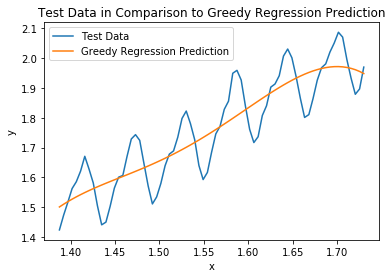

In [310]:
#Q5

#The code performs greedy regression by selecting basis functions to evaluate on the test set. The code prints the test RMSE of
#the prediction from the model created using the selected basis functions as well as plotting the predictions from the model
#with the test set. The code also prints the indices of the selected basis functions, and the type of basis function and its
#free parameter values.

greedy_regression()

#Results:

#Test RMSE: 0.08174109606847028

#[7139, 1007, 8435, 8445, 5206]
#(<function axcoswx at 0x00000122E7CD50D8>, (0.69, 0.37699111843077515))
#(<function acoswx at 0x00000122E7CF7A68>, (0.23, 0.37699111843077515))
#(<function ax2 at 0x00000122E7CF7318>, -0.98)
#(<function ax3 at 0x00000122E7CF7438>, -0.92)
#(<function axsinwx at 0x00000122E7CD5B88>, (0.23, 0.37699111843077515))